In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
db = sqlite3.connect("../data/checking-logs.sqlite")
sql = """
SELECT uid, timestamp
FROM checker
WHERE uid LIKE 'user_%'
  AND status = 'ready'
  AND labname = 'project1'
"""
df = pd.read_sql(sql, db, parse_dates=['timestamp'])

## 2. Preprocessing

In [3]:
df = df.sort_values(['uid', 'timestamp'])
df['numTrials'] = df.groupby('uid').cumcount() + 1
df.head()

,uid,timestamp,numTrials
886,user_1,2020-05-14 20:56:08.898880,1
887,user_1,2020-05-14 20:58:02.313690,2
888,user_1,2020-05-14 20:58:46.322457,3
900,user_1,2020-05-14 21:08:15.434237,4
901,user_1,2020-05-14 21:10:14.867603,5


## 3. Graph

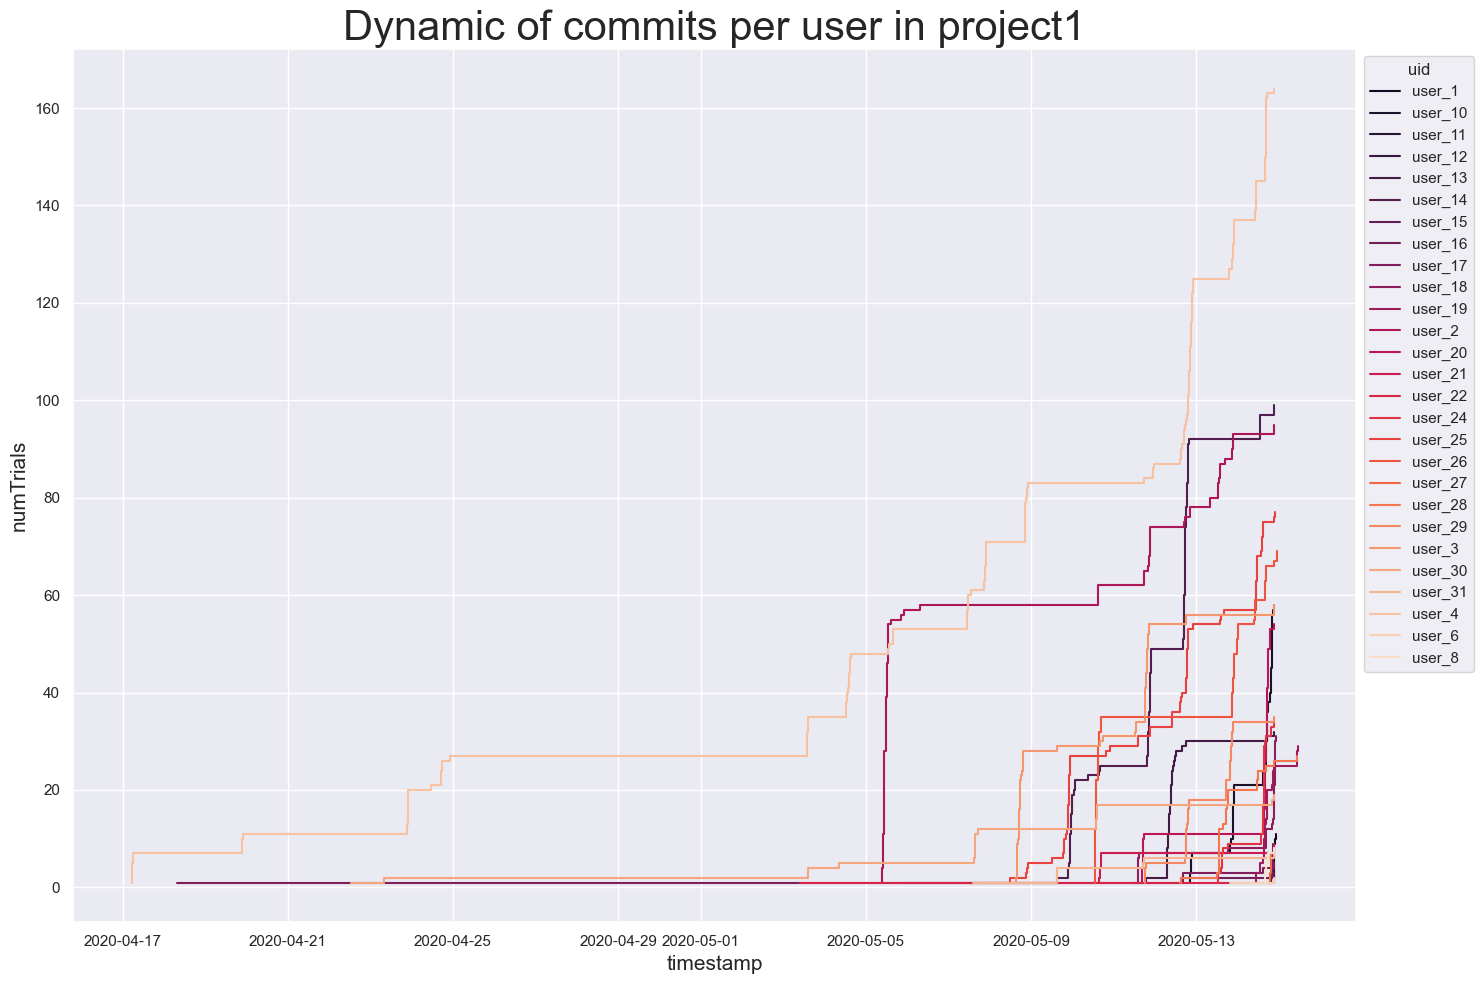

In [ ]:
sns.set_theme(style='darkgrid')
fig, ax = plt.subplots(figsize=(15, 10))
sns.lineplot(
    data=df, x='timestamp', y='numTrials', hue='uid',
    estimator=None, lw=3, palette='rocket', sort=False, ax=ax
)
for line in ax.lines:
    line.set_drawstyle('steps-post')
ax.set_title('Dynamic of commits per user in project1', fontsize=30)
ax.set_xlabel('timestamp', fontsize=15)
ax.set_ylabel('numTrials', fontsize=15)
ax.legend(title='uid', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## 4. Questions
"Which user was the leader in the number of commits almost all of the time?" 
- The answer is user_4.

"Which user was the leader for only a short period of time?"
- The answer is user_2.

## 4. Close

In [ ]:
db.close()